In [1]:
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import random
random.seed(1)
np.random.seed(1)

In [4]:
if "FitnessMin" in creator.__dict__:
    del creator.FitnessMin
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
K, T, S = 67, 90, 5
toolbox.register("attr_float", random.uniform, 0, 50)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, K*K*T)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

damp = 0.5
alpha_CVaR = 0.05
lambda_CVaR = 0.5
Max_dis = 70

cap = pd.read_excel("data/capacity2.xlsx", index_col=0)
dis = pd.read_excel("data/ordered_distance.xlsx", index_col=0)
A = pd.read_excel("data/A.xlsx", index_col=0)
N = pd.read_excel("data/pop.xlsx", index_col=0).values.flatten()
sus0 = pd.read_excel("data/S.xlsx", index_col=0)
inf0 = pd.read_excel("data/I.xlsx", index_col=0)
rec0 = pd.read_excel("data/R.xlsx", index_col=0)
alpha_df  = pd.read_excel("data/alpha_diversity_5.xlsx", index_col=[0])

beta = {1: 0.21598,2: 0.21598,3: 0.21598,4: 0.21598,5: 0.21598}
gamma = {1: 0.16453, 2: 0.19458, 3: 0.19188, 4: 0.19458, 5: 0.16453}
scenario_probs =   {1: 0.19206, 2: 0.19460, 3: 0.18341, 4: 0.20065, 5: 0.22928}
pr_arr = np.array([scenario_probs[s] for s in range(1, S+1)])
cap_arr = cap.values.flatten()
A_arr = A.values.flatten()


Gen 0: Best Obj = 4506515.03
Gen 1: Best Obj = 4506515.03
Gen 2: Best Obj = 4478847.71
Gen 3: Best Obj = 4428274.38
Gen 4: Best Obj = 4426288.21
Gen 5: Best Obj = 4401721.72
Gen 6: Best Obj = 4398169.02
Gen 7: Best Obj = 4392640.32
Gen 8: Best Obj = 4392640.32
Gen 9: Best Obj = 4388522.60
Gen 10: Best Obj = 4371468.34
Gen 11: Best Obj = 4357648.92
Gen 12: Best Obj = 4361376.55
Gen 13: Best Obj = 4358784.45
Gen 14: Best Obj = 4350944.91
Gen 15: Best Obj = 4350944.91
Gen 16: Best Obj = 4343868.95
Gen 17: Best Obj = 4343868.95
Gen 18: Best Obj = 4341500.03
Gen 19: Best Obj = 4335538.56


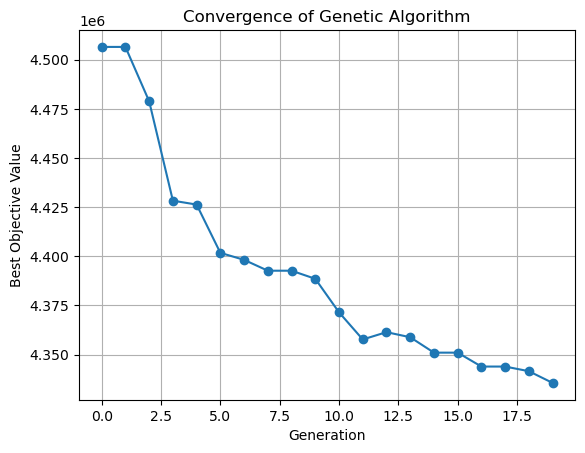

In [5]:
# Simulation
def simulate(x_vector):
    x_vector = np.clip(x_vector, 0, 500)
    x = np.reshape(x_vector, (K, K, T))
    AA = np.zeros((K, T))
    AA[:, 0] = A_arr

    sus = np.zeros((K, T + 1, S))
    inf = np.zeros((K, T + 1, S))
    rec = np.zeros((K, T + 1, S))
    unmet = np.zeros((K, T, S))

    for s in range(S):
        np.random.seed(s)
        sus[:, 0, s] = sus0.iloc[:, 0].values #* np.random.uniform(0.95, 1.05, K)
        inf[:, 0, s] = inf0.iloc[:, 0].values # * np.random.uniform(0.95, 1.05, K)
        rec[:, 0, s] = rec0.iloc[:, 0].values #* np.random.uniform(0.95, 1.05, K)

    for t in range(T):
        for i in range(K):
            for j in range(K):
                if i != j and dis.iloc[i, j] > Max_dis:
                    x[i, j, t] = 0

        for i in range(K):
            inflow = x[:, i, t].sum() - x[i, i, t]
            outflow = x[i, :, t].sum() - x[i, i, t]
            if t > 0:
                AA[i, t] = AA[i, t - 1] + inflow - outflow
            AA[i, t] = max(0, min(AA[i, t], cap_arr[i]))

            # Enforce x(i,j,t) ≤ AA(i,t)
            total_out = x[i, :, t].sum()
            if total_out > AA[i, t] and total_out > 0:
                ratio = AA[i, t] / total_out
                x[i, :, t] *= ratio   #x[i, :, t] = x[i, :, t] * ratio Ex: x[i, :, t] = [10, 20, 30] ratio = 0.5


        for s in range(S):
            s_id = s + 1
            b, g = beta[s_id], gamma[s_id]
            for j in range(K):
                damp_term = damp * sus[j, t, s] * sum(x[i, j, t] for i in range(K) if i != j)
                infect_term = b * inf[j, t, s] * sus[j, t, s]

                sus[j, t + 1, s] = np.clip(sus[j, t, s] - (infect_term + damp_term) / N[j], 0, N[j])
                inf[j, t + 1, s] = np.clip(inf[j, t, s] + (infect_term - damp_term) / N[j] - g * inf[j, t, s], 0, N[j])
                rec[j, t + 1, s] = np.clip(rec[j, t, s] + g * inf[j, t, s], 0, N[j])

                if (t + 1) in alpha_df.index and s_id in alpha_df.columns:
                    alpha_vals = np.array([alpha_df.loc[tt + 1, s_id] for tt in range(t + 1)]).flatten()
                    inf_slice = inf[j, max(0, t-9):t+1, s]
                    alpha_vals = alpha_vals[-len(inf_slice):]
                    alpha_roll = np.sum(alpha_vals * inf_slice)
                else:
                    inf_slice = inf[j, max(0, t-9):t+1, s]
                    alpha_vals = np.zeros(len(inf_slice))
                    alpha_roll = 0
                    
                unmet[j, t, s] = max(0, alpha_roll - AA[j, t])
                 




               
    return unmet, x, AA, sus, inf, rec


# Fitness function
def fitness(x_vector):
    unmet, _, _, _, _, _ = simulate(x_vector)
    total_unmet = unmet.sum(axis=0).sum(axis=0)
    xi = np.percentile(total_unmet, 100 * (1 - alpha_CVaR))
    etaa = np.maximum(total_unmet - xi, 0)
    cvar = xi + (1 / (1 - alpha_CVaR)) * np.dot(pr_arr, etaa)
    expected_unmet = np.dot(pr_arr, total_unmet)
    return expected_unmet + lambda_CVaR * cvar,


toolbox.register("evaluate", fitness)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

population = toolbox.population(n=10)
NGEN = 20
CXPB, MUTPB = 0.9, 0.1
best_vals = []

for gen in range(NGEN):
    offspring = algorithms.varAnd(population, toolbox, CXPB, MUTPB)
    fits = list(map(toolbox.evaluate, offspring))
    for ind, fit in zip(offspring, fits):
        ind.fitness.values = fit
    population = toolbox.select(offspring, k=len(population))
    best = tools.selBest(population, 1)[0]
    best_vals.append(best.fitness.values[0])
    print(f"Gen {gen}: Best Obj = {best.fitness.values[0]:.2f}")

# Convergence plot
plt.plot(best_vals, marker='o')
plt.title("Convergence of Genetic Algorithm")
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.grid(True)
plt.show()

In [6]:
best_ind = tools.selBest(population, 1)[0]
x_best = np.array(best_ind).reshape((K, K, T))
unmet_best, x_arr, AA_arr, sus_arr, inf_arr, rec_arr = simulate(x_best.flatten())

total_unmet = unmet_best.sum(axis=0).sum(axis=0)  # shape (S,)
xi = np.percentile(total_unmet, 100 * (1 - alpha_CVaR))
etaa = np.maximum(total_unmet - xi, 0)
cvar = lambda_CVaR * (xi + (1 / (1 - alpha_CVaR)) * np.dot(pr_arr, etaa))
UD = np.dot(pr_arr, total_unmet)
total_infected = inf_arr.sum()
print("Total unmet demand (per scenario):", total_unmet)
print("Xi (CVaR cutoff):", xi)

Total unmet demand (per scenario): [2983005.33198761 1773849.48663808 1980292.23377033 1117244.8656762
 3984826.53988781]
Xi (CVaR cutoff): 3784462.2983077676
